In [2]:
import os
import sys

os.environ["PYSYN_CDBS"] = "/Users/winstonzhang/Code/GitHub/SPISEA/cdbs"
os.environ["SPISEA_MODELS"] = "/Users/winstonzhang/Code/GitHub/SPISEA"

sys.path.append("/Users/winstonzhang/Code/GitHub/SPISEA")

Isochrone loaded from existing file: .//iso_6.00_1.12_04500_p0.00.fits
Isochrone loaded from existing file: .//iso_6.30_0.78_04500_p0.00.fits


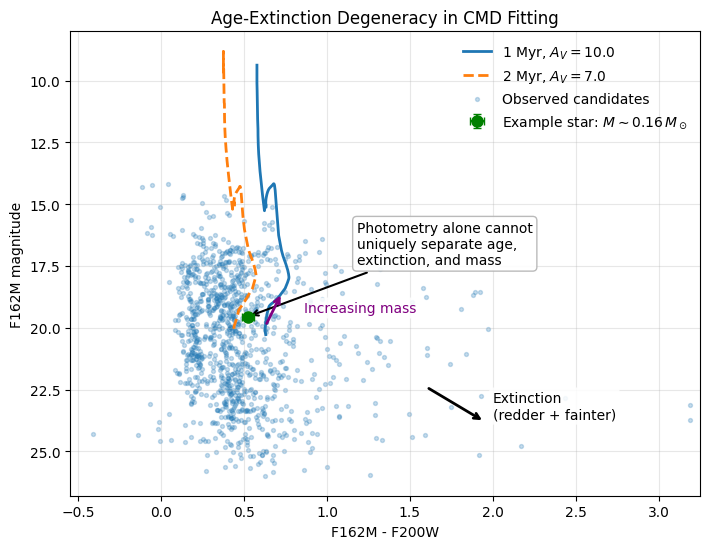

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening

# -----------------------------
# Load observed data
# -----------------------------
data = np.loadtxt("winstonlist.dat")

x = data[:, 0]
y = data[:, 1]
f162 = data[:, 2]
ef162 = data[:, 3]
f182 = data[:, 4]
ef182 = data[:, 5]
f200 = data[:, 6]
ef200 = data[:, 7]
av_fit = data[:, 8]
mass_fit = data[:, 9]

color = f162 - f200
color_err = np.sqrt(ef162**2 + ef200**2)

# Choose a star near the proposed IMF peak
target_mass = 0.16
idx = np.argmin(np.abs(mass_fit - target_mass))

# -----------------------------
# SPISEA isochrone generator
# -----------------------------
def make_isochrone(age_myr=1.0, AKs=0.0, distance=4500):
    evo_model = evolution.MISTv1()
    atm_func = atmospheres.get_merged_atmosphere
    red_law = reddening.RedLawHosek18b()

    iso = synthetic.IsochronePhot(
        logAge=np.log10(age_myr * 1e6),
        AKs=AKs,
        distance=distance,
        evo_model=evo_model,
        atm_func=atm_func,
        red_law=red_law,
        filters=["jwst,F162M", "jwst,F182M", "jwst,F200W"],
    )
    return iso


def extract_iso(iso):
    tab = iso.points

    # Uncomment if column names break:
    # print(tab.keys())

    mass = tab["mass"]
    m162 = tab["m_jwst_F162M"]
    m182 = tab["m_jwst_F182M"]
    m200 = tab["m_jwst_F200W"]

    return mass, m162, m182, m200


def av_to_aks(AV):
    # approximate conversion for schematic figure
    return 0.112 * AV


# Illustrative reddening values
AV_1myr = 10.0
AV_2myr = 7.0

iso_1 = make_isochrone(age_myr=1.0, AKs=av_to_aks(AV_1myr))
iso_2 = make_isochrone(age_myr=2.0, AKs=av_to_aks(AV_2myr))

mass1, iso162_1, iso182_1, iso200_1 = extract_iso(iso_1)
mass2, iso162_2, iso182_2, iso200_2 = extract_iso(iso_2)

iso_color_1 = iso162_1 - iso200_1
iso_color_2 = iso162_2 - iso200_2

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 5.6))

# Isochrones
ax.plot(
    iso_color_1,
    iso162_1,
    lw=2,
    label=fr"1 Myr, $A_V={AV_1myr}$",
)

ax.plot(
    iso_color_2,
    iso162_2,
    lw=2,
    linestyle="--",
    label=fr"2 Myr, $A_V={AV_2myr}$",
)

# Observed stars
ax.scatter(
    color,
    f162,
    s=8,
    alpha=0.25,
    label="Observed candidates",
)

# Highlight target star once
ax.errorbar(
    color[idx],
    f162[idx],
    xerr=color_err[idx],
    yerr=ef162[idx],
    fmt="o",
    markersize=8,
    capsize=3,
    color="green",
    ecolor="green",
    label=fr"Example star: $M \sim {mass_fit[idx]:.2f}\,M_\odot$",
    zorder=5,
)

# Main degeneracy annotation: move it to open space
ax.annotate(
    "Photometry alone cannot\nuniquely separate age,\nextinction, and mass",
    xy=(color[idx], f162[idx]),
    xytext=(1.18, 16.6),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="black"),
    fontsize=10,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9),
)

# Extinction vector: place in lower-right open area
x_ext0 = 1.60
y_ext0 = 22.4
dx_ext = 0.35
dy_ext = 1.4

ax.annotate(
    "",
    xy=(x_ext0 + dx_ext, y_ext0 + dy_ext),
    xytext=(x_ext0, y_ext0),
    arrowprops=dict(arrowstyle="->", lw=2, color="black"),
)

ax.text(
    x_ext0 + dx_ext + 0.05,
    y_ext0 + dy_ext * 0.55,
    "Extinction\n(redder + fainter)",
    fontsize=10,
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
)

# Mass direction arrow: along the 1 Myr isochrone
m_low = 0.12
m_high = 0.30

idx_low = np.argmin(np.abs(mass1 - m_low))
idx_high = np.argmin(np.abs(mass1 - m_high))

ax.annotate(
    "",
    xy=(iso_color_1[idx_high], iso162_1[idx_high]),
    xytext=(iso_color_1[idx_low], iso162_1[idx_low]),
    arrowprops=dict(arrowstyle="->", lw=2, color="purple"),
)

ax.text(
    0.86,
    19.2,
    "Increasing mass",
    fontsize=10,
    color="purple",
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
)

# Formatting
ax.set_xlabel("F162M - F200W")
ax.set_ylabel("F162M magnitude")
ax.set_title("Age-Extinction Degeneracy in CMD Fitting")
ax.invert_yaxis()
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper right")

# Optional axis limits to preserve open label space
ax.set_xlim(-0.55, 3.25)
ax.set_ylim(26.8, 8.0)

fig.tight_layout()
# fig.savefig("cmd_age_extinction_degeneracy.png", dpi=300)
# fig.savefig("cmd_age_extinction_degeneracy.pdf")
plt.show()

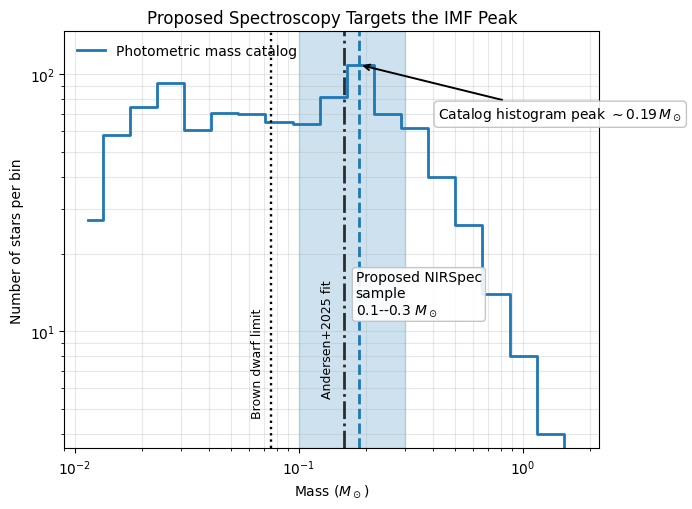

In [12]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("winstonlist.dat")
mass = data[:, -1]

mass = mass[np.isfinite(mass)]
mass = mass[mass > 0]

bins = np.logspace(np.log10(0.01), np.log10(2.0), 20)
hist, edges = np.histogram(mass, bins=bins)
bin_centers = np.sqrt(edges[:-1] * edges[1:])

peak_idx = np.argmax(hist)
peak_mass = bin_centers[peak_idx]
peak_count = hist[peak_idx]

fig, ax = plt.subplots(figsize=(7.0, 5.2))

ax.step(
    bin_centers,
    hist,
    where="mid",
    lw=2,
    label="Photometric mass catalog",
)

# Proposed target region
ax.axvspan(0.1, 0.3, alpha=0.22, color="tab:blue")
ax.text(
    0.18,
    14,
    "Proposed NIRSpec\nsample\n0.1--0.3 $M_\\odot$",
    fontsize=10,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.75", alpha=0.9),
)

# Catalog histogram peak
ax.axvline(peak_mass, linestyle="--", linewidth=2, color="tab:blue")
ax.annotate(
    fr"Catalog histogram peak $\sim {peak_mass:.2f}\,M_\odot$",
    xy=(peak_mass, peak_count),
    xytext=(0.42, 70),
    arrowprops=dict(arrowstyle="->", lw=1.4),
    fontsize=10,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.75", alpha=0.9),
)

# Andersen et al. 2025 fitted IMF peak
andersen_peak = 0.16
ax.axvline(andersen_peak, linestyle="-.", linewidth=2, color="black", alpha=0.8)
ax.text(
    andersen_peak * 0.90,   
    5.5,
    r"Andersen+2025 fit",
    fontsize=9,
    rotation=90,
    ha="right",
    va="bottom",
)

# Brown dwarf boundary
bd_limit = 0.075
ax.axvline(bd_limit, linestyle=":", linewidth=1.7, color="black")
ax.text(
    bd_limit * 0.93,
    4.6,
    "Brown dwarf limit",
    fontsize=9,
    rotation=90,
    ha="right",
    va="bottom",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Mass ($M_\odot$)")
ax.set_ylabel("Number of stars per bin")
ax.set_title("Proposed Spectroscopy Targets the IMF Peak")
ax.grid(alpha=0.3, which="both")

ax.legend(frameon=False, loc="upper left")

ax.set_xlim(0.009, 2.2)
ax.set_ylim(3.5, max(hist) * 1.35)

fig.tight_layout()
# fig.savefig("imf_s284_targets.png", dpi=300)
# fig.savefig("imf_s284_targets.pdf")
plt.show()